# 🎲 GeoMAS — Variance & Determinism Analysis

Questo notebook è dedicato all'analisi della devianza (o varianza) tra diverse simulazioni eseguite a **Temperatura 0** con lo **stesso Seed iniziale**. L'obiettivo è quantificare eventuali divergenze comportamentali dovute al non-determinismo intrinseco dei modelli LLM (es. differenze minime nel processing floating-point dei token o cache-hit/miss sulle API di Anthropic/OpenAI, parallelizzazioni async).

| Run ID | Descrizione |
|---|---|
| **62** | Run Identica 1 |
| **63** | Run Identica 2 |
| **64** | Run Identica 3 |

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Setup Stile
sns.set_theme(style='darkgrid', context='talk')
plt.rcParams['figure.figsize'] = (16, 8)

METRICS_DB = 'simulation_metrics.duckdb'

def query_metrics(query, params=None):
    if params:
        params = [p.item() if hasattr(p, 'item') else p for p in params]
    with duckdb.connect(METRICS_DB, read_only=True) as conn:
        return conn.execute(query, params or []).df()

# Definisci qui le run da confrontare
TARGET_SIMS = ['3', '4', '5']

print(f"Database: {METRICS_DB}")
print(f"Confrontando le Simulazioni: {TARGET_SIMS}")

Database: simulation_metrics.duckdb
Confrontando le Simulazioni: ['3', '4', '5']


## 1. Caricamento Dati Globali

In [2]:
# Carica metriche globali per le simulazioni target
query_g = f"""
SELECT * FROM metrics_global 
WHERE simulation_id IN ({','.join(['?']*len(TARGET_SIMS))}) 
ORDER BY simulation_id, turn
"""
global_df = query_metrics(query_g, TARGET_SIMS)
global_df['simulation_id'] = global_df['simulation_id'].astype(str)

print(f"Metriche globali caricate: {len(global_df)} righe.")
display(global_df.groupby('simulation_id')['turn'].max().to_frame('Max Turn'))

Metriche globali caricate: 150 righe.


,Max Turn
simulation_id,
3,50
4,50
5,50


## 2. Devianza Aggregata (Global Metrics)
Se il determinismo è perfetto, le linee di queste run **devono sovrapporsi perfettamente**, producendo deviazione standard pari a zero.

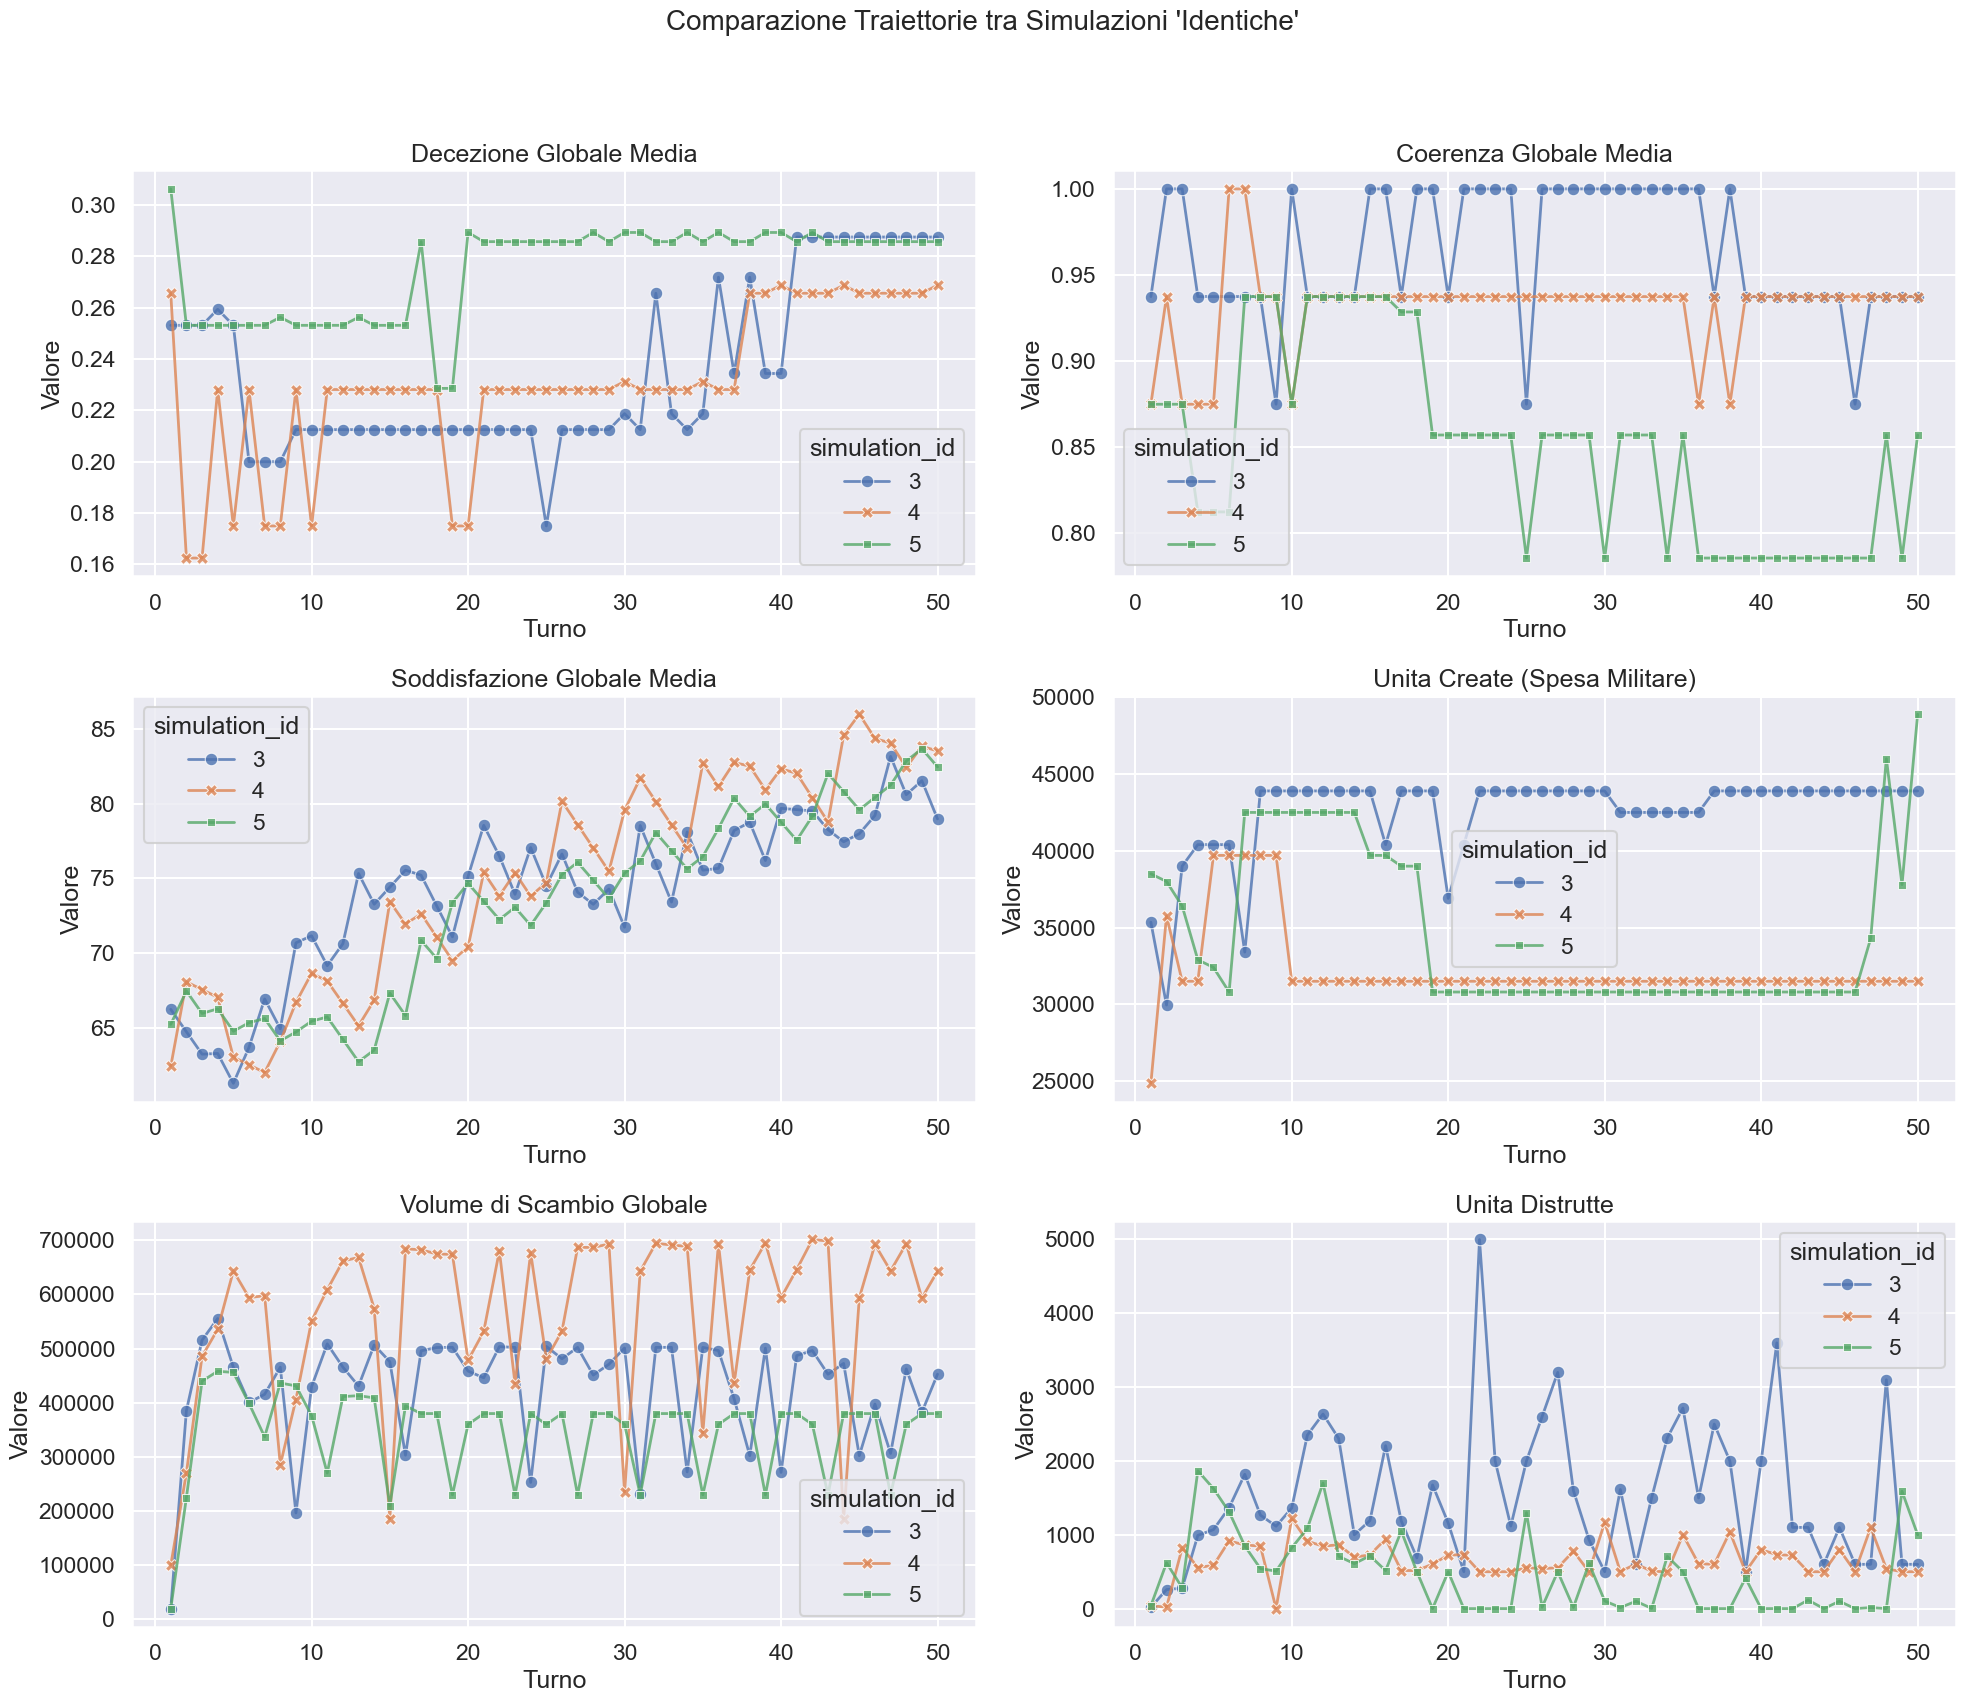

In [3]:
metrics_to_plot = [
    ('global_deception_avg', 'Decezione Globale Media'),
    ('global_coherence_avg', 'Coerenza Globale Media'),
    ('global_satisfaction_avg', 'Soddisfazione Globale Media'),
    ('units_created', 'Unita Create (Spesa Militare)'),
    ('global_trade_volume', 'Volume di Scambio Globale'),
    ('units_destroyed', 'Unita Distrutte')
]

fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle("Comparazione Traiettorie tra Simulazioni 'Identiche'", fontsize=20)

for i, (col, title) in enumerate(metrics_to_plot):
    ax = axes[i // 2][i % 2]
    # Disegna ogni simulazione con una linea sottile e marcatori
    sns.lineplot(
        data=global_df, x='turn', y=col, 
        hue='simulation_id', style='simulation_id', 
        markers=True, dashes=False, ax=ax, linewidth=2, alpha=0.8
    )
    ax.set_title(title)
    ax.set_xlabel('Turno')
    ax.set_ylabel('Valore')
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3. Quantificazione della Devianza (Variance Analysis)
Calcoliamo esplicitamente la deviazione standard per ogni turno su metriche chiave. Se la Dev Std > 0 in un dato turno, significa che lì è avvenuta la prima **divergenza (farfalla del caos)**.

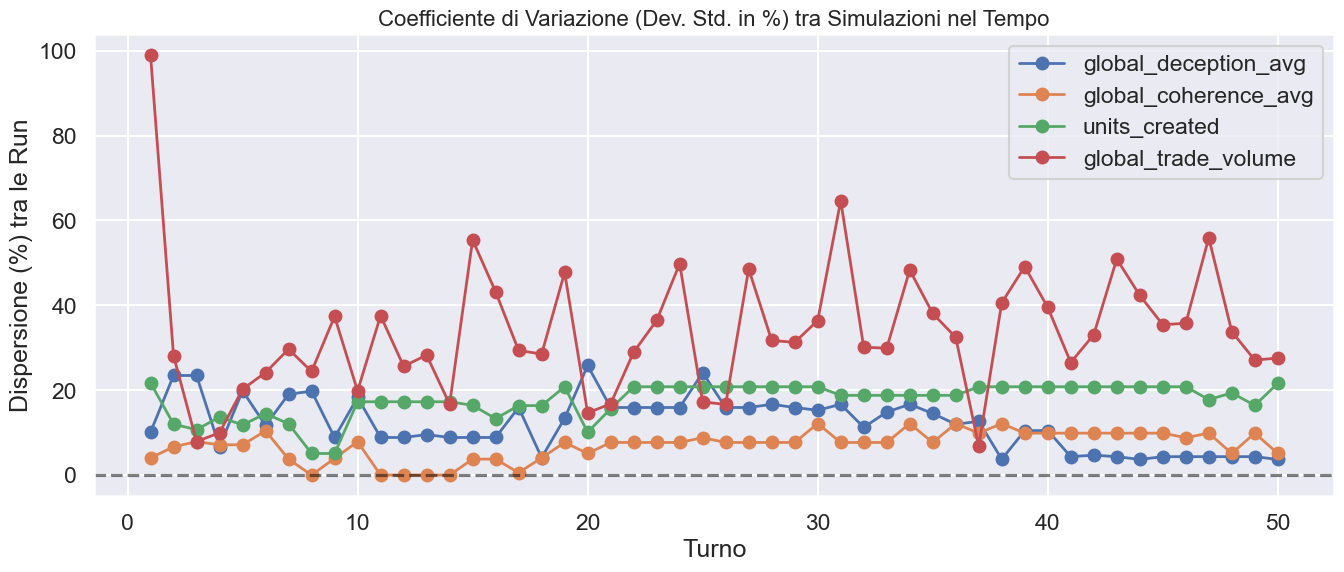

Top 5 Turni con Massima Devianza (Coeff. Variazione Globale Medio in %):


,Media CV%
turn,
31,37.808369
22,37.750782
23,34.556079
27,34.139384
19,34.019364


In [4]:
cols = [m[0] for m in metrics_to_plot]

# Calcola STD tra simulazioni per ogni turno
std_df = global_df.groupby('turn')[cols].std().fillna(0)

# Calcola la devianza percentuale (Rispetto alla media!)
mean_df = global_df.groupby('turn')[cols].mean().replace(0, np.nan)
cv_df = (std_df / mean_df * 100).fillna(0) # Coeff. of Variation (%)

fig, ax = plt.subplots(figsize=(16, 6))
for col in ['global_deception_avg', 'global_coherence_avg', 'units_created', 'global_trade_volume']:
    ax.plot(cv_df.index, cv_df[col], label=col, marker='o', linewidth=2)

ax.set_title('Coefficiente di Variazione (Dev. Std. in %) tra Simulazioni nel Tempo', fontsize=16)
ax.set_xlabel('Turno')
ax.set_ylabel('Dispersione (%) tra le Run')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.legend()
plt.show()

print("Top 5 Turni con Massima Devianza (Coeff. Variazione Globale Medio in %):")
display(cv_df.mean(axis=1).sort_values(ascending=False).head(5).to_frame('Media CV%'))

## 4. Zoom a livello di Nazione (Power Projection)
Anche se i valori medi globali sono simili, le singole nazioni potrebbero aver intrapreso strade diverse.

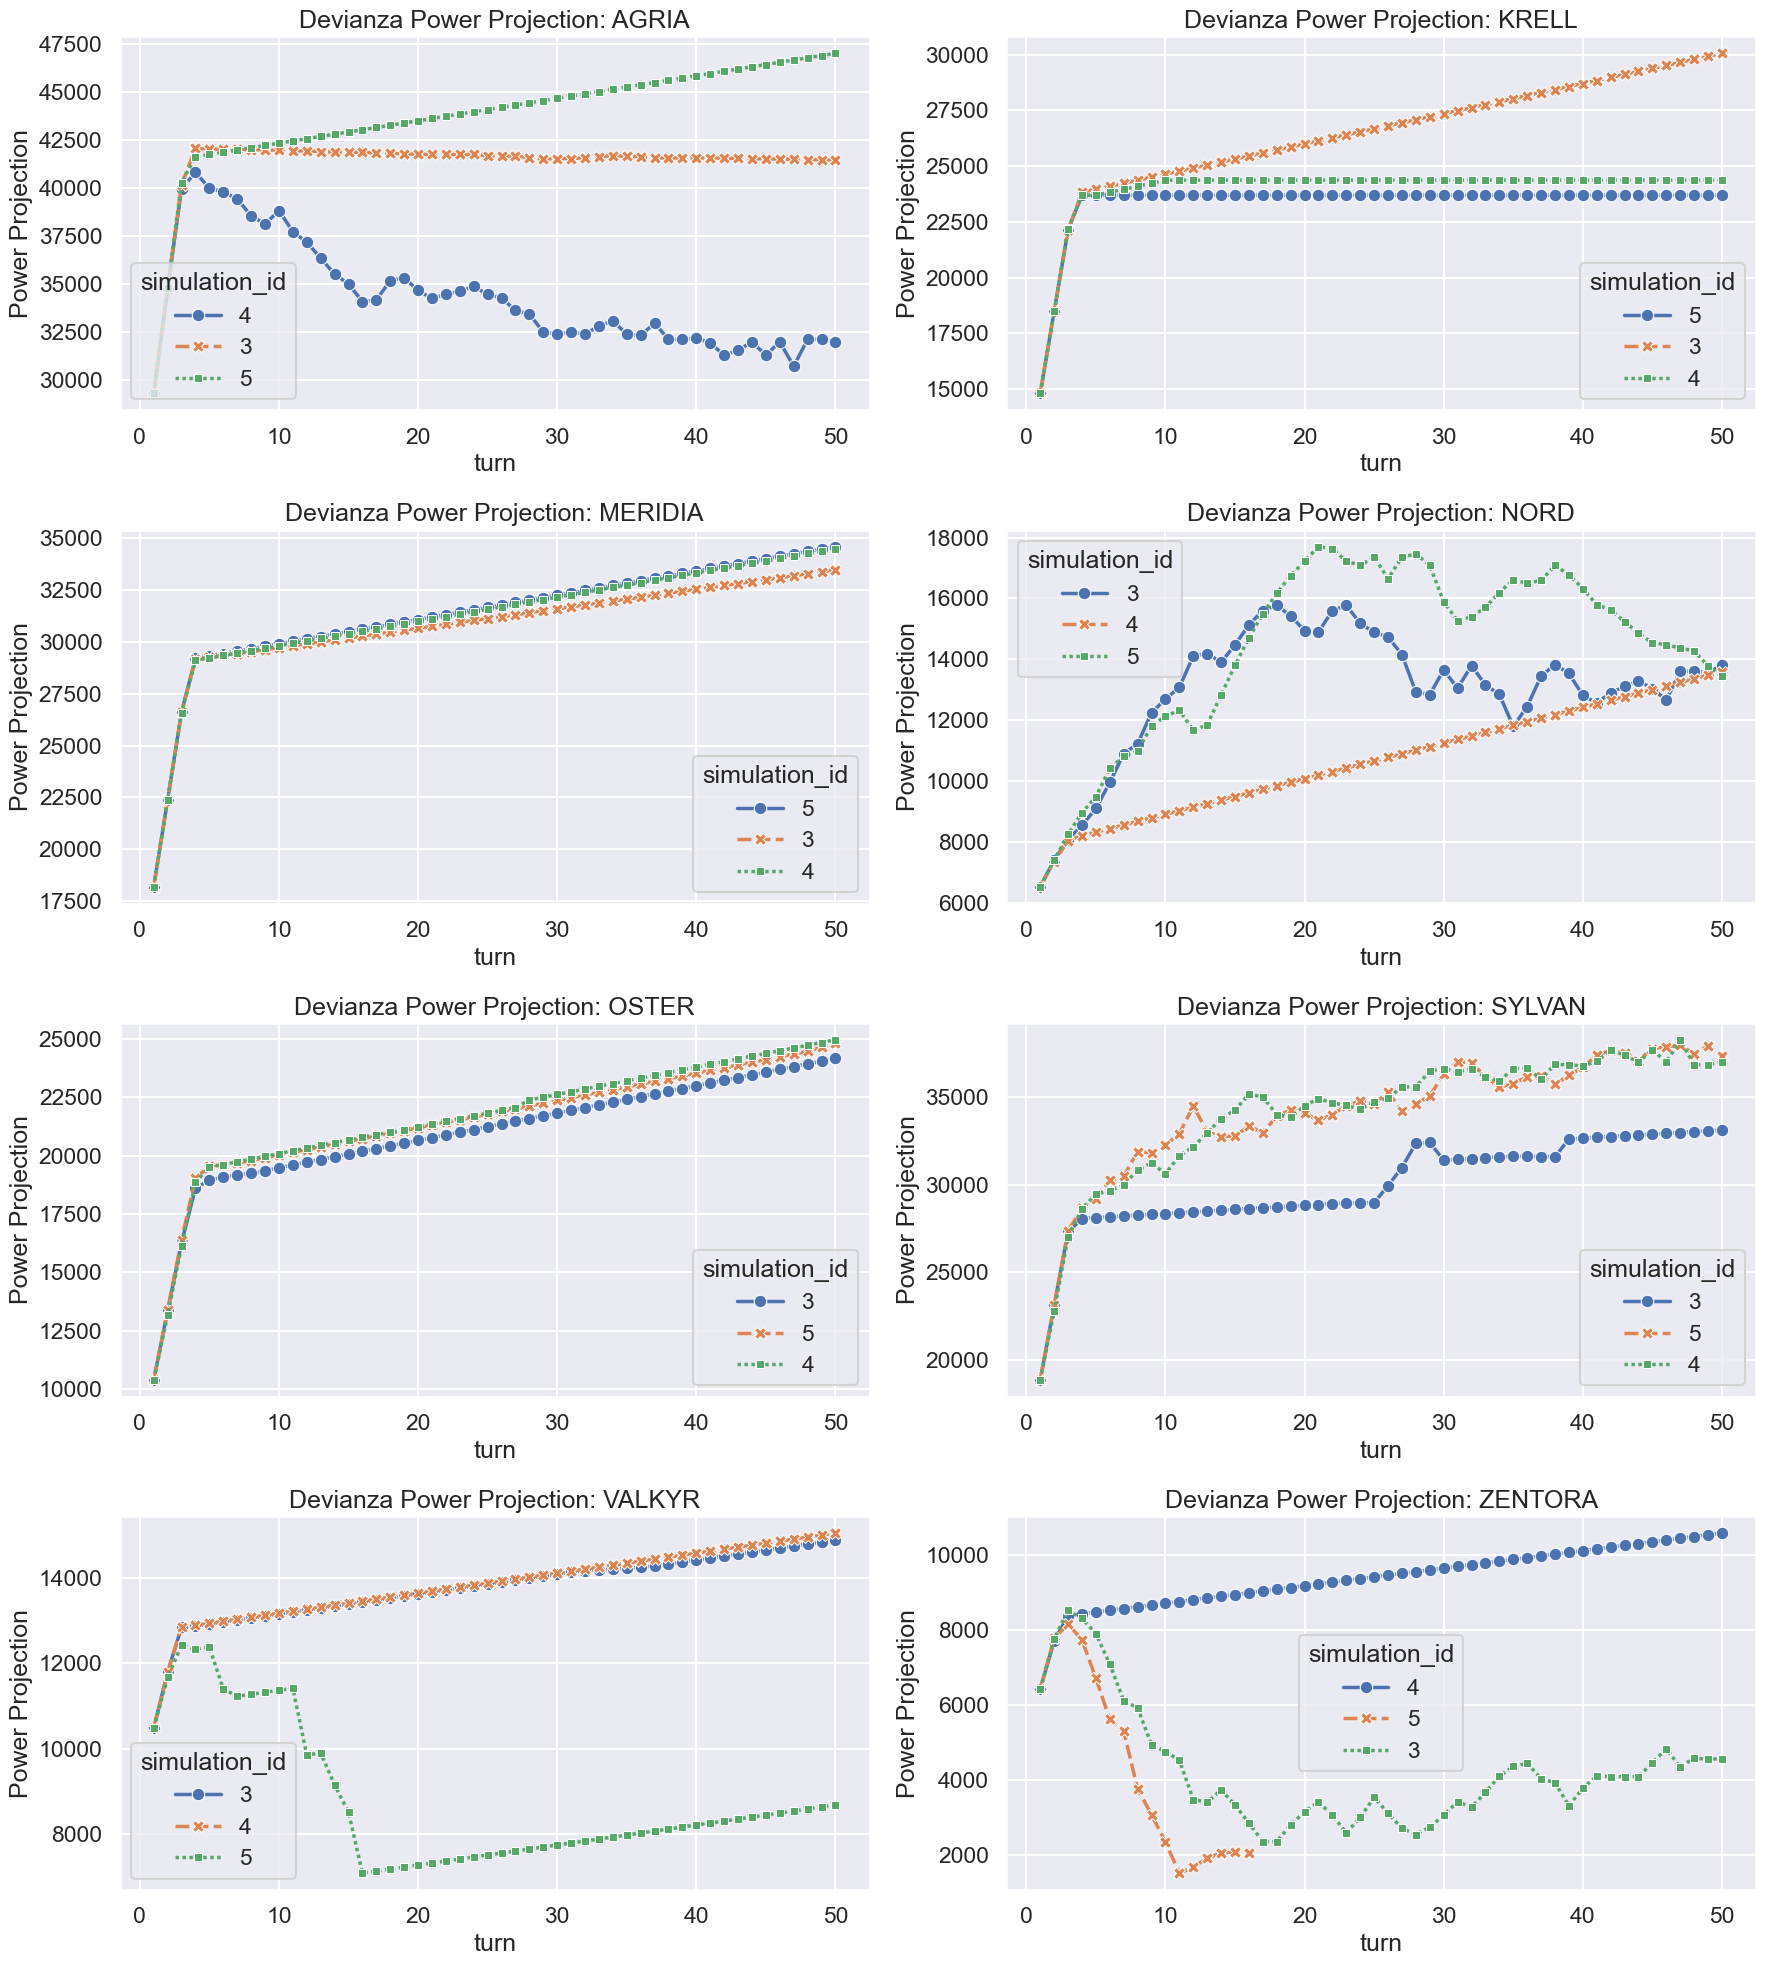

In [5]:
query_n = f"""
SELECT simulation_id, turn, nation_id, power_projection, budget, soldiers
FROM metrics_nation 
WHERE simulation_id IN ({','.join(['?']*len(TARGET_SIMS))}) 
ORDER BY turn, nation_id
"""
nation_df = query_metrics(query_n, TARGET_SIMS)
nation_df['simulation_id'] = nation_df['simulation_id'].astype(str)

nations = nation_df['nation_id'].unique()
fig, axes = plt.subplots(int(np.ceil(len(nations)/2)), 2, figsize=(18, 5 * int(np.ceil(len(nations)/2))))
axes = axes.flatten()

for i, nation in enumerate(nations):
    subset = nation_df[nation_df['nation_id'] == nation]
    sns.lineplot(
        data=subset, x='turn', y='power_projection', 
        hue='simulation_id', style='simulation_id', 
        ax=axes[i], linewidth=2.5, markers=True
    )
    axes[i].set_title(f'Devianza Power Projection: {nation}')
    axes[i].set_ylabel('Power Projection')

plt.tight_layout()
plt.show()

## Conclusioni della Varianza
- **Divergenza Iniziale:** Osserva in quale `turn` le curve (e la Dev Std) si separano dallo zero.
- **Divergenza Terminale:** Valuta se le run esplodono in scenari diametralmente opposti o se alla fine convergono in uno stato simile (macro-stato stabile nonostante differenze di micro-traiettoria).
- **Determinismo Stretto:** Se tutte le tabelle riportano devianza 0, il determinismo è stato mantenuto con successo.